In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv('../data/clean/Data_cleaning_wrangling.csv',low_memory=False)

## Q1: Overall Demand Trend Over Time

In [2]:
df.columns

Index(['invoice_id', 'line', 'customer_id', 'product_id', 'unit_price',
       'quantity', 'date', 'discount', 'line_total', 'store_id', 'employee_id',
       'currency', 'currency_symbol', 'sku', 'transaction_type',
       'payment_method', 'invoice_total', 'Month', 'Year', 'Day', 'category',
       'sub_category', 'description_pt', 'description_de', 'description_fr',
       'description_es', 'description_en', 'description_zh', 'production_cost',
       'country', 'city', 'store_name', 'number_of_employees', 'zip_code',
       'latitude', 'longitude', 'day_of_the_week', 'is_discounted',
       'price_bin'],
      dtype='str')

In [3]:

daily_demand = (
    df.groupby(['Year', 'Month', 'Day'])['quantity']
    .sum()
    .reset_index()
)

# On average, how many units do we sell per day in each year
yearly_demand = (
    daily_demand.groupby('Year')['quantity']
    .mean().round(2)
)

print(yearly_demand)

Year
2023    19185.25
2024    20925.50
2025    12987.24
Name: quantity, dtype: float64


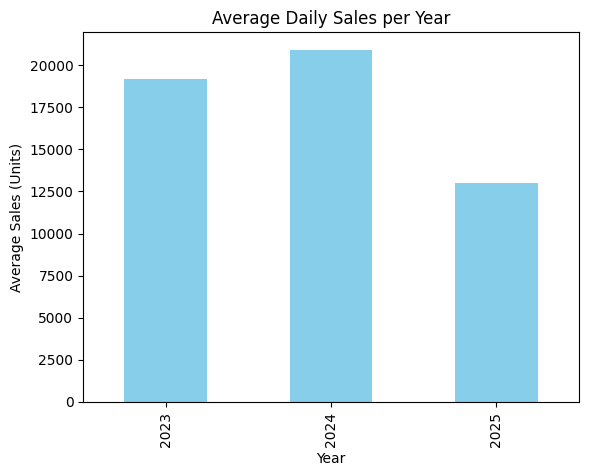

In [4]:

# Create a bar plot
yearly_demand.plot(kind='bar', color='skyblue')

# Add titles and labels
plt.title('Average Daily Sales per Year')
plt.xlabel('Year')
plt.ylabel('Average Sales (Units)')

# Show the plot
plt.show()

In [5]:
#On average, how many units do we sell per day in each month across years
monthly_demand = (
    daily_demand.groupby(['Year', 'Month'])['quantity']
    .mean().round(2)
)

print(monthly_demand)

Year  Month
2023  1        14519.43
      2        10401.86
      3        21716.86
      4        15520.57
      5        17169.86
      6        10826.71
      7        12618.57
      8        10782.00
      9        26391.29
      10       23836.57
      11       15960.14
      12       50479.14
2024  1        15013.43
      2        12679.29
      3        23980.00
      4        16466.00
      5        16172.71
      6        12616.14
      7        12733.29
      8        12726.86
      9        29646.86
      10       25177.86
      11       18109.57
      12       55784.00
2025  1        15140.00
      2        12138.14
      3        11683.57
Name: quantity, dtype: float64


In [6]:
monthly_demand2 = (
    daily_demand.groupby(['Month'])['quantity']
    .mean().round(2)
)

print(monthly_demand2)

Month
1     14890.95
2     11739.76
3     19126.81
4     15993.29
5     16671.29
6     11721.43
7     12675.93
8     11754.43
9     28019.07
10    24507.21
11    17034.86
12    53131.57
Name: quantity, dtype: float64


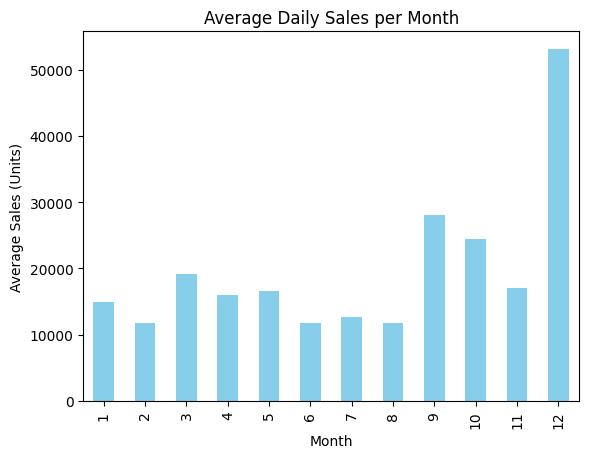

In [7]:

# Create a bar plot
monthly_demand2.plot(kind='bar', color='skyblue')

# Add titles and labels
plt.title('Average Daily Sales per Month')
plt.xlabel('Month')
plt.ylabel('Average Sales (Units)')

# Show the plot
plt.show()

In [8]:
day_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}


df['day_of_the_week'] = df['Day'].map(day_mapping)

In [9]:
weekday_demand = df.groupby('day_of_the_week')['quantity'].sum().reset_index()

In [10]:
weekday_demand['day_of_the_week'] = pd.Categorical(
    weekday_demand['day_of_the_week'],
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)


weekday_demand = weekday_demand.sort_values('day_of_the_week')

print(weekday_demand)

  day_of_the_week  quantity
1          Monday    449767
5         Tuesday    394867
6       Wednesday    412341
4        Thursday    387997
0          Friday    392260
2        Saturday    788066
3          Sunday    816737


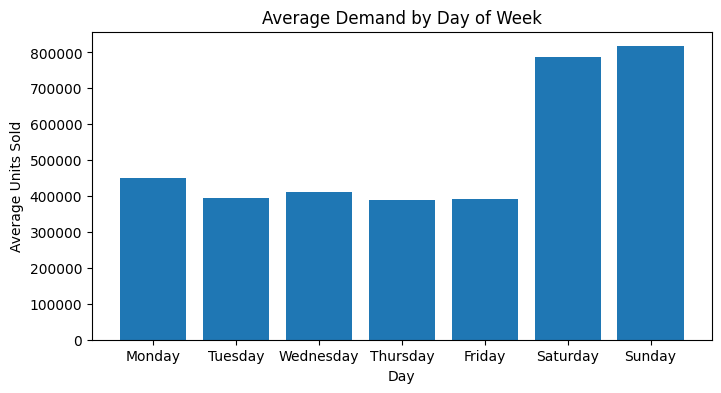

In [11]:
plt.figure(figsize=(8,4))
plt.bar(weekday_demand['day_of_the_week'], weekday_demand['quantity'])
plt.title('Average Demand by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Units Sold')
plt.show()

In [12]:
# Volatine demand analysis

mean_demand = weekday_demand['quantity'].mean()
std_demand = weekday_demand['quantity'].std()



In [13]:
# coefficient variance < 0.30 demand is stable / > 0.70 highly volatile 

cv = std_demand / mean_demand

print(f"Mean demand: {mean_demand:.2f}")
print(f"Std deviation: {std_demand:.2f}")
print(f"Coefficient of Variation (CV): {cv:.2f}")




Mean demand: 520290.71
Std deviation: 194008.31
Coefficient of Variation (CV): 0.37


**With a CV of 0.37:
Daily demand typically fluctuates by ±37% around the mean
Large swings exist, but they are manageable
Safety stock is required**

## Q2: Which categories drive most of the demand?

In [14]:
category_demand = df.groupby('category')['quantity'].sum().reset_index()


In [15]:
total_quantity = category_demand['quantity'].sum()
category_demand['proportion'] = category_demand['quantity'] / total_quantity * 100

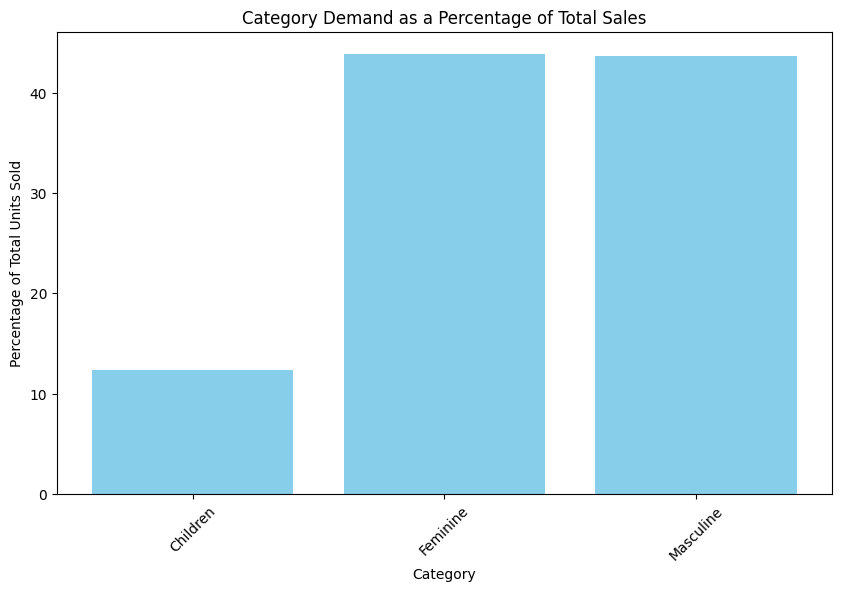

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(category_demand['category'], category_demand['proportion'], color='skyblue')
plt.title('Category Demand as a Percentage of Total Sales')
plt.xlabel('Category')
plt.ylabel('Percentage of Total Units Sold')
plt.xticks(rotation=45)
plt.show()

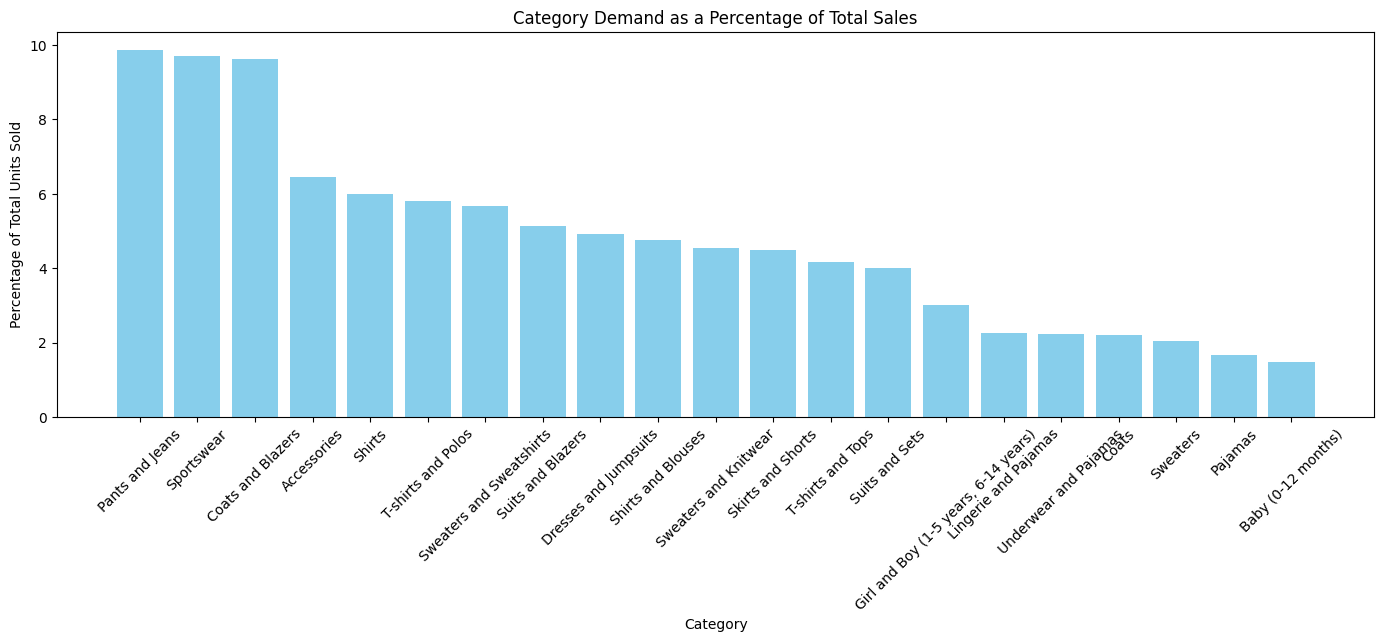

In [63]:
# comulative view

category_demand = df.groupby('sub_category')['quantity'].sum().reset_index()


total_quantity = category_demand['quantity'].sum()
category_demand['proportion'] = category_demand['quantity'] / total_quantity * 100

#Sort from biggest to smallest

category_demand = category_demand.sort_values(
    by='proportion',
    ascending=False
)

plt.figure(figsize=(17, 5))
plt.bar(category_demand['sub_category'], category_demand['proportion'], color='skyblue')
plt.title('Category Demand as a Percentage of Total Sales')
plt.xlabel('Category')
plt.ylabel('Percentage of Total Units Sold')
plt.xticks(rotation=45)
ha='right'
#plt.tight_layout() 


plt.show()





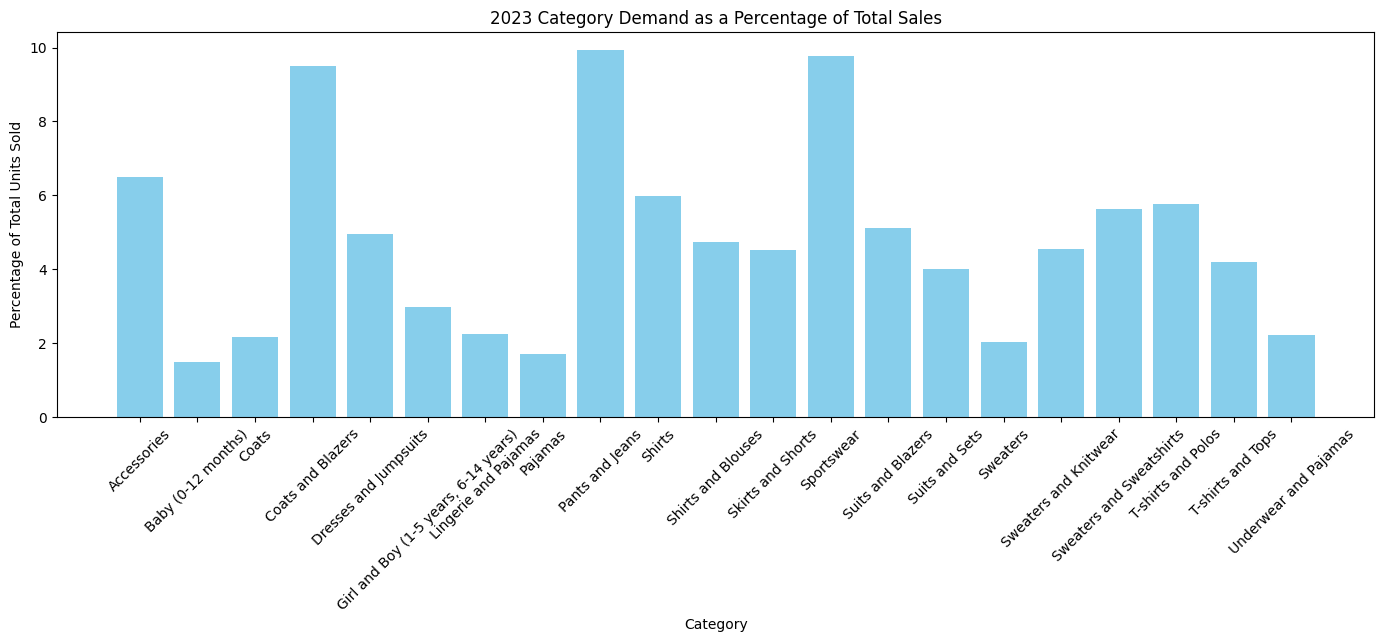

In [18]:
# filter 2023 vs 2024

filtered_df = df[df['Year'] == 2023]

# Now perform the groupby operation with the filtered data
category_demand = filtered_df.groupby('sub_category')['quantity'].sum().reset_index()

total_quantity = category_demand['quantity'].sum()
category_demand['proportion'] = category_demand['quantity'] / total_quantity * 100

plt.figure(figsize=(17, 5))
plt.bar(category_demand['sub_category'], category_demand['proportion'], color='skyblue')
plt.title('2023 Category Demand as a Percentage of Total Sales')
plt.xlabel('Category')
plt.ylabel('Percentage of Total Units Sold')
plt.xticks(rotation=45)
plt.show()

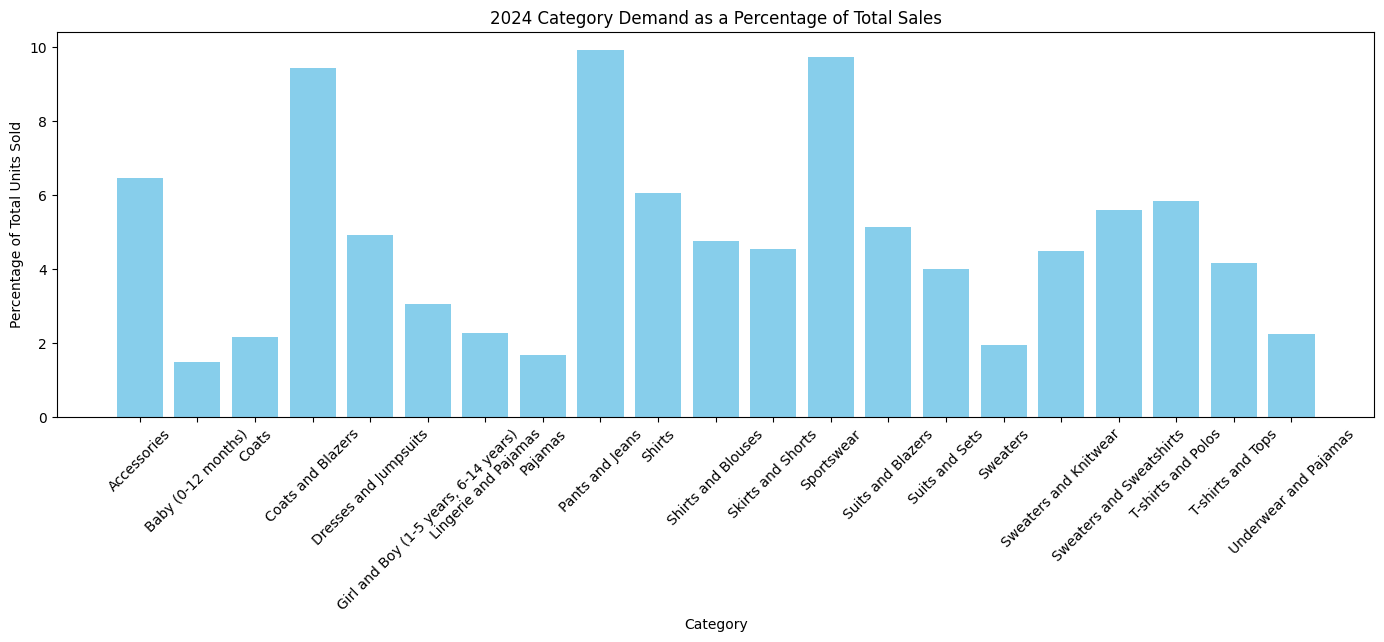

In [19]:
filtered_df2 = df[df['Year']== 2024]

# Now perform the groupby operation with the filtered data
category_demand = filtered_df2.groupby('sub_category')['quantity'].sum().reset_index()

total_quantity = category_demand['quantity'].sum()
category_demand['proportion'] = category_demand['quantity'] / total_quantity * 100

plt.figure(figsize=(17, 5))
plt.bar(category_demand['sub_category'], category_demand['proportion'], color='skyblue')
plt.title('2024 Category Demand as a Percentage of Total Sales')
plt.xlabel('Category')
plt.ylabel('Percentage of Total Units Sold')
plt.xticks(rotation=45)
plt.show()

In [20]:
cat_month = (
    df.groupby(['sub_category', 'Month'])['quantity']
    .mean()
    .reset_index()
)


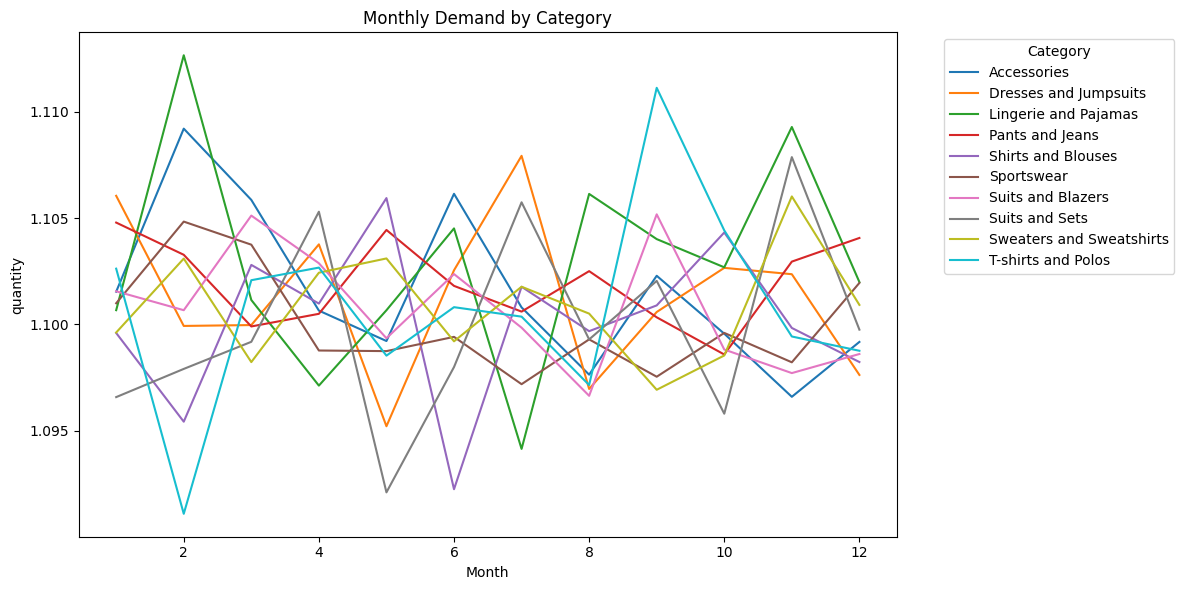

In [64]:

# Determine the top 10 categories by total quantity
top_categories = (
    cat_month.groupby('sub_category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filter 'cat_month' to only include these top categories
filtered_cat_month = cat_month[cat_month['sub_category'].isin(top_categories)]

# Plot the data
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_cat_month,
    x='Month',
    y='quantity',
    hue='sub_category'
)
plt.title('Monthly Demand by Category')

plt.legend(
    title='Category',
    bbox_to_anchor=(1.05, 1), # pushes legend out of the graph
    loc='upper left' # anchor the legend on the top right 
)

plt.tight_layout()


plt.show()


## Q3: Does discounting significantly increase demand?

In [22]:
# add discount flag in df

df['is_discounted'] = df['discount'].fillna(0).apply(lambda x: 1 if x > 0 else 0)


In [23]:
df['is_discounted'].value_counts()

is_discounted
0    2417134
1     893390
Name: count, dtype: int64

In [24]:
# Total units sold per day under discounted vs non-discounted conditions

daily_discount_demand = (
    df.groupby(['Day', 'is_discounted'])['quantity']
    .sum()
    .reset_index()
)


In [25]:
# On average, how many units are sold per day when discounted vs full price?

avg_demand = (
    daily_discount_demand.groupby('is_discounted')['quantity'].mean().reset_index()
)

avg_demand['price_type'] = avg_demand['is_discounted'].map({      #map --> dictionary 
    0: 'Full Price',
    1: 'Discounted'
})

print(avg_demand)

# Extract the demand values for Discounted and Full Price
discounted_demand = daily_discount_demand[daily_discount_demand['is_discounted'] == 1]['quantity']
full_price_demand = daily_discount_demand[daily_discount_demand['is_discounted'] == 0]['quantity']

total_avg_demand = avg_demand['quantity'].sum()


avg_demand['percentage'] = (
    avg_demand['quantity'] / total_avg_demand * 100
).round(2)

print(avg_demand['percentage'])

   is_discounted       quantity  price_type
0              0  379940.714286  Full Price
1              1  140350.000000  Discounted
0    73.02
1    26.98
Name: percentage, dtype: float64


In [26]:
# Group by discount percent and sum the units sold
discount_summary = df.groupby('discount')['quantity'].sum().reset_index()

# Calculate the percentage of units sold for each discount type
total_units_sold = df['quantity'].sum()
discount_summary['Percent_of_Total_Sold'] = (discount_summary['quantity'] / total_units_sold * 100).round(2)

print(discount_summary)

   discount  quantity  Percent_of_Total_Sold
0      0.00   2659585                  73.02
1      0.20     82195                   2.26
2      0.25     77852                   2.14
3      0.35    121664                   3.34
4      0.40     72728                   2.00
5      0.45    134963                   3.71
6      0.50    474210                  13.02
7      0.60     18838                   0.52


## Hypothesis testing 
**Does discounting increase demand?**

# Statistical hypotheses
- H₀ (Null hypothesis):
- Discounted products do not sell more units per day than when they are not discounted.
- H0: mean_Q_with_discount <= mean_Q_without_discount
- H1: mean_Q_with_discount > mean_Q_without_discount
- H₁ (Alternative hypothesis):
- Discounted products sell more units per day than when they are not discounted.

In [27]:
correlation = daily_discount_demand[['is_discounted', 'quantity']].corr()
print(correlation)


               is_discounted  quantity
is_discounted       1.000000 -0.772558
quantity           -0.772558  1.000000


In [28]:
# The correlation between is_discounted and quantity is -0.763639, which indicates a strong negative correlation. This suggests that as is_discounted increases, quantity tends to decrease.
# no linear relationship

In [29]:
# T- Test 

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    discounted_demand,
    full_price_demand,
    alternative='greater'   # business hypothesis
)

print(p_value)

0.9994001265643604


In [30]:
# Discounted demand is NOT greater than full-price demand
# in both t-test and mannwhitneyu tests p value = 1 --> The observed data strongly contradicts the alternative hypothesis you tested.Demand during discount periods is not higher, and is very likely lower or equal.
# Discounts do not significantly increase unit demand even at the product level. --> risk of demand cannibalization 


In [31]:
# mannwhitneyu test --> data does not follow normal distribution

discounted_products = df[df['discount'] > 0]['product_id'].unique()

df_test = df[df['product_id'].isin(discounted_products)]


In [32]:
product_daily_demand = (
    df_test
    .groupby(['product_id', 'date', 'is_discounted'])['quantity']
    .sum()
    .reset_index()
)


In [33]:
discounted = product_daily_demand[
    product_daily_demand['is_discounted'] == 1
]['quantity']

full_price = product_daily_demand[
    product_daily_demand['is_discounted'] == 0
]['quantity']

from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    discounted,
    full_price,
    alternative='greater'
)

print(p_value)


1.0


In [34]:
# connection python --> sql ( df-already cleaned or singular RAW DATABASE- define relationship)

# new schema in SQL - name it -apply ( in python create a link into project_schema) 

# Q4: Are there significant differences in demand across stores or regions?

In [35]:
# consistent daily time frame

store_daily_demand = (
    df.groupby(['store_id','country','city','Day'])['quantity']
    .sum()
    .reset_index()
)

In [36]:
country_avg = (
    store_daily_demand
    .groupby('country')['quantity']
    .mean()
    .sort_values(ascending=False)
)


/Users/chiara/Ironhack/Final_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chiara/Ironhack/Final_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


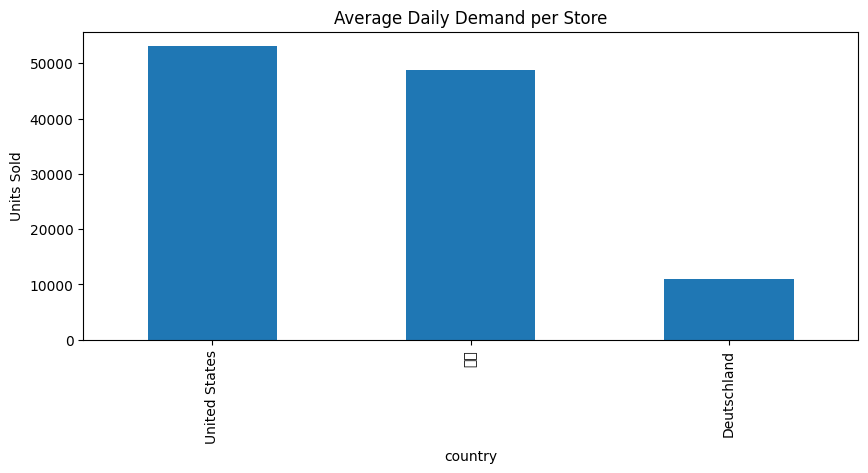

In [37]:

plt.figure(figsize=(10,4))
country_avg.plot(kind='bar')
plt.title('Average Daily Demand per Store')
plt.ylabel('Units Sold')
plt.show()


/Users/chiara/Ironhack/Final_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chiara/Ironhack/Final_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chiara/Ironhack/Final_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24191 (\N{CJK UNIFIED IDEOGRAPH-5E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chiara/Ironhack/Final_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24030 (\N{CJK UNIFIED IDEOGRAPH-5DDE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/chiara/Ironhack/Final_project/.venv/lib/p

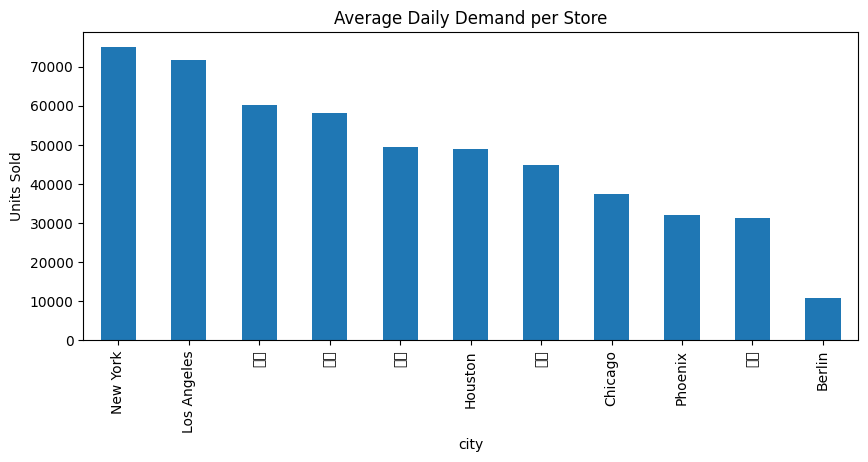

In [38]:
city_avg = (
    store_daily_demand
    .groupby('city')['quantity']
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(10,4))
city_avg.plot(kind='bar')
plt.title('Average Daily Demand per Store')
plt.ylabel('Units Sold')
plt.show()

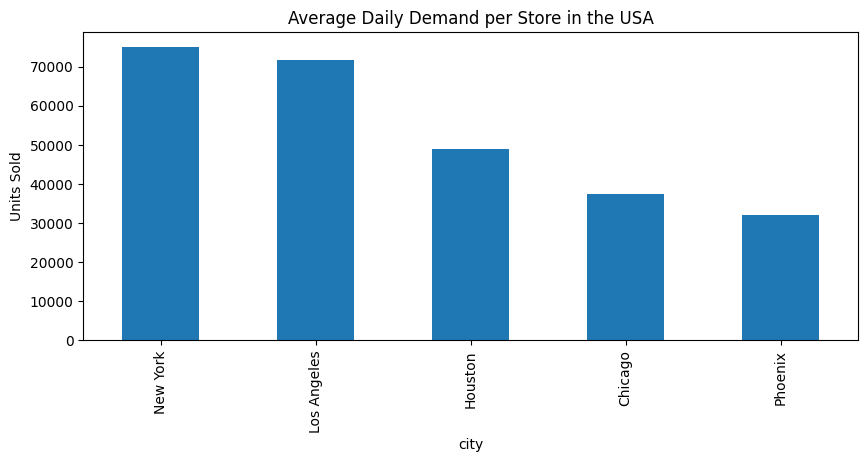

In [39]:
# filter on USA

city_avg = (
    store_daily_demand[store_daily_demand['country'] == 'United States']  # First filter by country
    .groupby('city')['quantity']  # Then group by city
    .mean()  # Calculate the mean
    .sort_values(ascending=False)  # Sort values
)

plt.figure(figsize=(10, 4))
city_avg.plot(kind='bar')  # Plot the data
plt.title('Average Daily Demand per Store in the USA')  # Title
plt.ylabel('Units Sold')  # Y-axis label
plt.show()

# Hypothesis test
- Null hypo: There is a statistically significant difference in demand across the cities in the same country
- Alternative hypo :  There is not a statistically significant difference in demand across the cities in the same country

In [40]:
import scipy.stats as stats

# Group data by city
cities = store_daily_demand['city'].unique()

# Create a list with demand data for each city
demand_data = [store_daily_demand[store_daily_demand['city'] == city]['quantity'] for city in cities]

# Perform ANOVA test
f_statistic, p_value = stats.f_oneway(*demand_data)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

# Interpret the p-value
alpha = 0.05
if p_value < alpha:
    print("There is a statistically significant difference in demand across the cities (reject null hypothesis).")
else:
    print("There is no statistically significant difference in demand across the cities (fail to reject null hypothesis).")

F-statistic: 6.9394078840684825
P-value: 2.5745088455681267e-07
There is a statistically significant difference in demand across the cities (reject null hypothesis).


In [41]:
# Demand differs significantly across cities, indicating strong local demand patterns even within the same country.
# local replenishment strategy 

# Q5: What are the key factors that explain demand variability in fashion retail
- Price
- Discounts
- Seasonality
- Product category

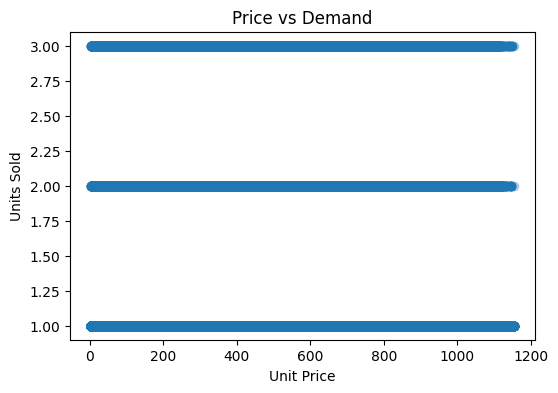

In [42]:
# price vs demand.

# in this database demand is limited as the qty is only 1,2,3 --> Aggregate demand before plotting


import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['unit_price'], df['quantity'], alpha=0.3)
plt.xlabel('Unit Price')
plt.ylabel('Units Sold')
plt.title('Price vs Demand')
plt.show()


#At transaction level, quantity is almost constant → price elasticity cannot be observed directly.

In [43]:
df['price_bin'] = pd.qcut(df['unit_price'], q=10)  # price buckets


In [44]:
price_demand = (
    df.groupby('price_bin')['quantity']
    .count()   # count 
)


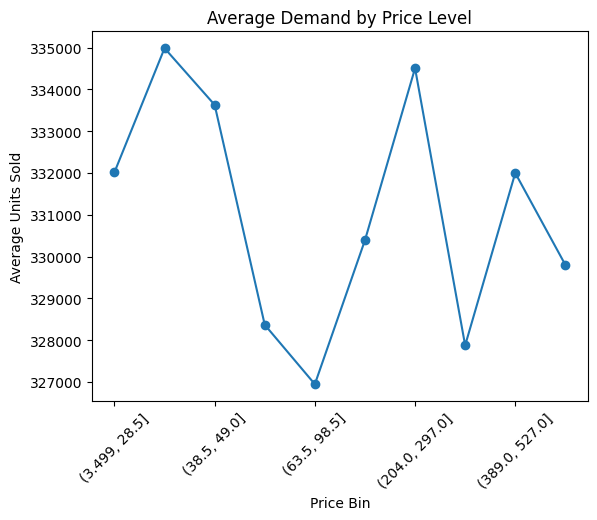

In [45]:
price_demand.plot(marker='o')
plt.title('Average Demand by Price Level')
plt.xlabel('Price Bin')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=45)
plt.show()


In [46]:
# aggregation product level

product_price_demand = (
    df.groupby('product_id')
    .agg(
        avg_price=('unit_price', 'mean'),
        avg_units=('quantity', 'mean')
    )
)


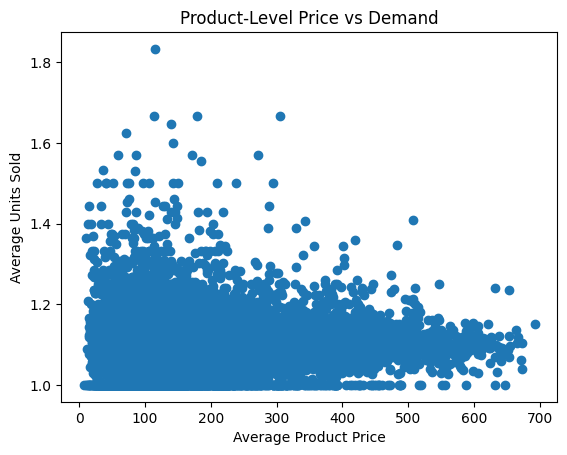

In [47]:
plt.scatter(
    product_price_demand['avg_price'],
    product_price_demand['avg_units']
)
plt.xlabel('Average Product Price')
plt.ylabel('Average Units Sold')
plt.title('Product-Level Price vs Demand')
plt.show()


In [48]:
# Higher-priced products tend to sell fewer units per transaction - High dispersion at low prices

#Price shows a weak negative relationship with demand and explains less variability compared to category and seasonality, suggesting relatively inelastic demand in this dataset


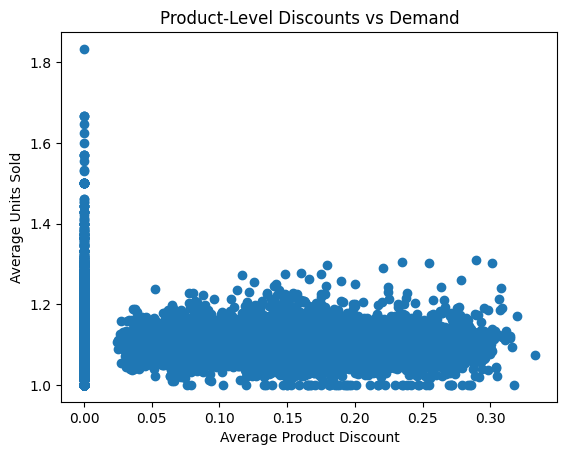

In [49]:
# Discount vs demand

# Aggregation at the product level
product_discount_demand = (
    df.groupby('product_id')
    .agg(
        avg_discount=('discount', 'mean'),  # Assuming 'discount' is the column name
        avg_units=('quantity', 'mean')
    )
)

plt.scatter(
    product_discount_demand['avg_discount'],
    product_discount_demand['avg_units']
)
plt.xlabel('Average Product Discount')
plt.ylabel('Average Units Sold')
plt.title('Product-Level Discounts vs Demand')
plt.show()

In [50]:
# no predominant demand driver due to lack of clear slope
# Discount shows a weak negative relationship 

Text(0, 0.5, 'Average Units Sold')

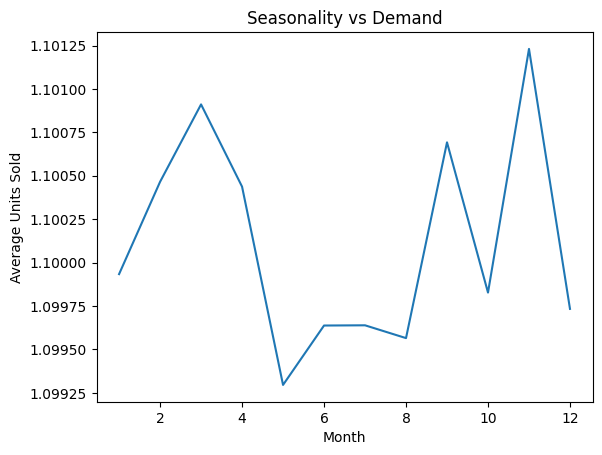

In [51]:
# seasonaly vs demand 

# plt.savefig("../figures/filename.png") --> to save the figures in a folder 

seasonality_demand = (
    df.groupby('Month') 
    .agg(
        avg_units=('quantity', 'mean')
    )
)

fig, axes = plt.subplots()
sns.lineplot(data=seasonality_demand, x="Month", y="avg_units", ax=axes)
axes.set_title('Seasonality vs Demand')
axes.set_xlabel('Month')
axes.set_ylabel('Average Units Sold')

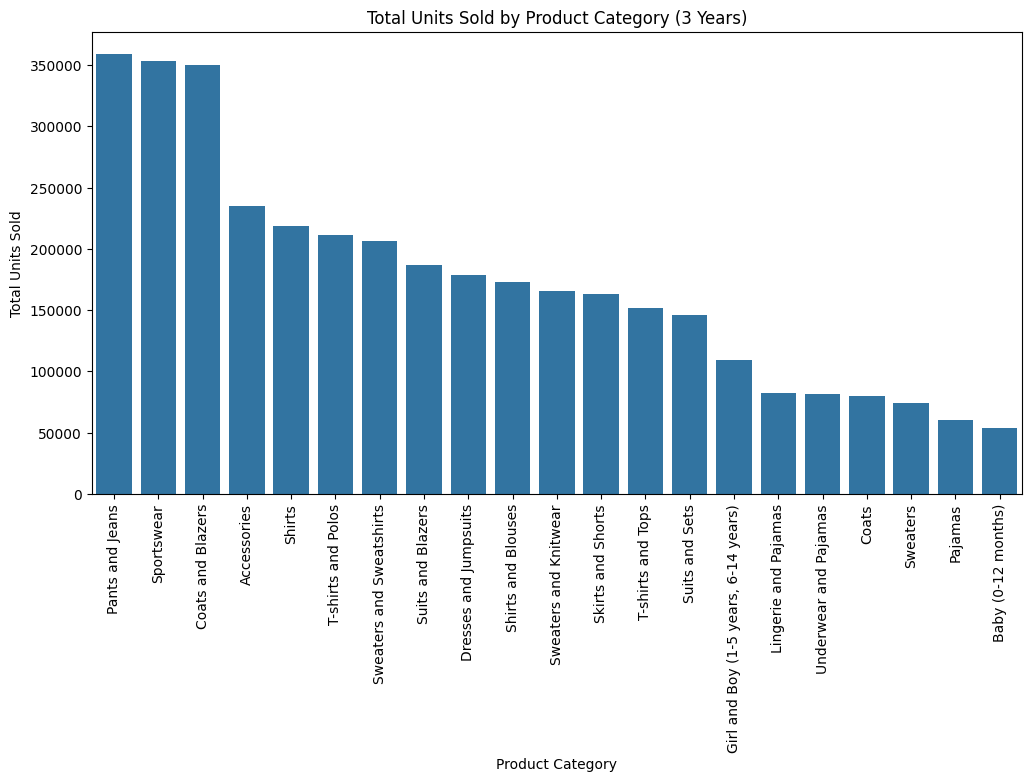

In [52]:
category_demand = (
    df.groupby('sub_category')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)


plt.figure(figsize=(12,6))
sns.barplot(
    data=category_demand,
    x='sub_category',
    y='quantity'
)

plt.title('Total Units Sold by Product Category (3 Years)')
plt.xlabel('Product Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=90)
plt.show()


In [53]:
category_demand['demand_share'] = (
    category_demand['quantity'] /
    category_demand['quantity'].sum()
) * 100


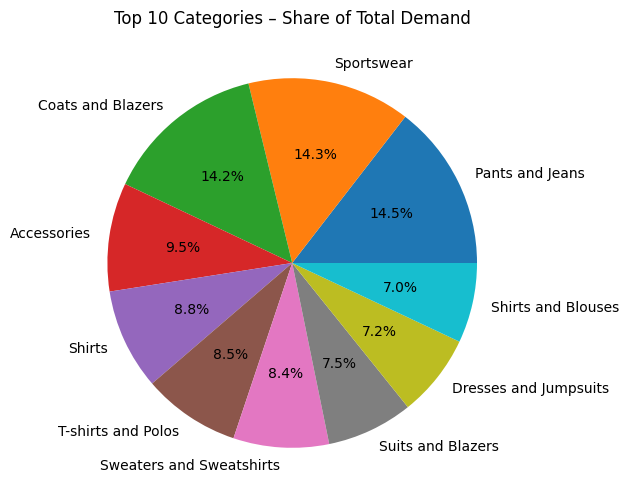

In [54]:
top_categories = category_demand.head(10)

plt.figure(figsize=(8,6))
plt.pie(
    top_categories['demand_share'],
    labels=top_categories['sub_category'],
    autopct='%1.1f%%'
)
plt.title('Top 10 Categories – Share of Total Demand')
plt.show()


In [55]:
#df.to_csv('/Users/Chiara/Ironhack/Final_project/data/clean/Data_cleaning_wrangling.csv',index=False) # export an updated df to work on the forecasting model 

In [56]:
df.head()

,invoice_id,line,customer_id,product_id,unit_price,quantity,date,discount,line_total,store_id,...,country,city,store_name,number_of_employees,zip_code,latitude,longitude,day_of_the_week,is_discounted,price_bin
0,INV-US-001-03558761,1,47162,485,80.5,1,2023-01-01 15:42:00,0.0,80.5,1,...,United States,New York,Store New York,10,10001,40.7128,-74.006,Sunday,0,"(63.5, 98.5]"
1,INV-US-001-03558761,2,47162,2779,31.5,1,2023-01-01 15:42:00,0.4,18.9,1,...,United States,New York,Store New York,10,10001,40.7128,-74.006,Sunday,1,"(28.5, 38.5]"
2,INV-US-001-03558761,3,47162,64,45.5,1,2023-01-01 15:42:00,0.4,27.3,1,...,United States,New York,Store New York,10,10001,40.7128,-74.006,Sunday,1,"(38.5, 49.0]"
3,INV-US-001-03558762,1,10142,131,70.0,1,2023-01-01 20:04:00,0.4,42.0,1,...,United States,New York,Store New York,10,10001,40.7128,-74.006,Sunday,1,"(63.5, 98.5]"
4,INV-US-001-03558762,2,10142,716,26.0,1,2023-01-01 20:04:00,0.0,26.0,1,...,United States,New York,Store New York,10,10001,40.7128,-74.006,Sunday,0,"(3.499, 28.5]"
